In [1]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


# Analisi Esplorativa Avanzata del Dataset GUIDE

Questo notebook contiene un'analisi dettagliata del dataset GUIDE, focalizzandosi su:

1. Correlazioni tra attributi
2. Distribuzione del rischio (Risk)
3. Analisi delle categorie (AlertTitle, IncidentGrade)
4. Analisi temporale dei dati
5. Pattern settimanali
6. Altre analisi rilevanti

In [2]:
# Importazione delle librerie necessarie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Impostazioni di visualizzazione
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = [12, 8]

# Caricamento del dataset
df = pd.read_csv('../data/GUIDE_Train.csv')

print("Dimensioni del dataset:", df.shape)
print("\nPrime righe del dataset:")
display(df.head())

Dimensioni del dataset: (9516837, 45)

Prime righe del dataset:


,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,ActionGrouped,ActionGranular,EntityType,EvidenceRole,DeviceId,Sha256,IpAddress,Url,AccountSid,AccountUpn,AccountObjectId,AccountName,DeviceName,NetworkMessageId,EmailClusterId,RegistryKey,RegistryValueName,RegistryValueData,ApplicationId,ApplicationName,OAuthApplicationId,ThreatFamily,FileName,FolderPath,ResourceIdName,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City
0,180388628218,0,612,123247,2024-06-04T06:05:15.000Z,7,6,InitialAccess,NaN,TruePositive,NaN,NaN,Ip,Related,98799,138268,27,160396,441377,673934,425863,453297,153085,529644,NaN,1631,635,860,2251,3421,881,NaN,289573,117668,3586,NaN,NaN,5,66,NaN,NaN,NaN,31,6,3
1,455266534868,88,326,210035,2024-06-14T03:01:25.000Z,58,43,Exfiltration,NaN,FalsePositive,NaN,NaN,User,Impacted,98799,138268,360606,160396,22406,23032,22795,24887,153085,529644,NaN,1631,635,860,2251,3421,881,NaN,289573,117668,3586,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
2,1056561957389,809,58352,712507,2024-06-13T04:52:55.000Z,423,298,InitialAccess,T1189,FalsePositive,NaN,NaN,Url,Related,98799,138268,360606,68652,441377,673934,425863,453297,153085,529644,NaN,1631,635,860,2251,3421,881,NaN,289573,117668,3586,NaN,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630
3,1279900258736,92,32992,774301,2024-06-10T16:39:36.000Z,2,2,CommandAndControl,NaN,BenignPositive,NaN,NaN,Url,Related,98799,138268,360606,13,441377,673934,425863,453297,153085,529644,NaN,1631,635,860,2251,3421,881,NaN,289573,117668,3586,NaN,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630
4,214748368522,148,4359,188041,2024-06-15T01:08:07.000Z,9,74,Execution,NaN,TruePositive,NaN,NaN,User,Impacted,98799,138268,360606,160396,449,592,440,479,153085,529644,NaN,1631,635,860,2251,3421,881,NaN,289573,117668,3586,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630


## Analisi della Distribuzione della Colonna Target

Analizziamo la distribuzione della colonna IncidentGrade.

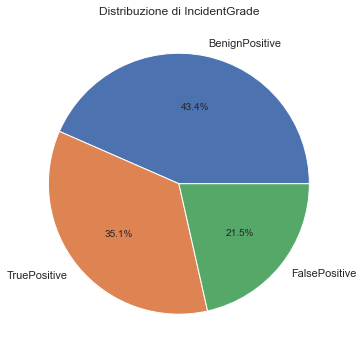

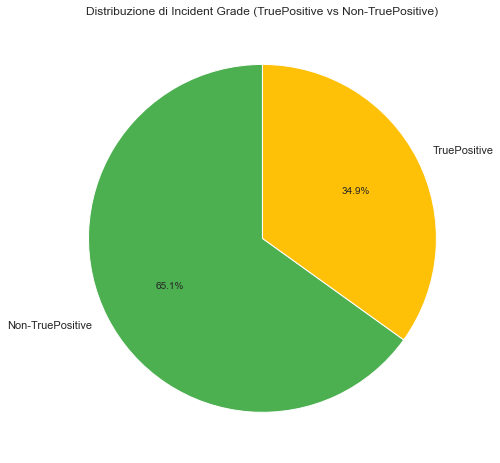

In [3]:
# Analisi di IncidentGrade
plt.figure(figsize=(10, 6))
incident_counts = df['IncidentGrade'].value_counts()
plt.pie(incident_counts, labels=incident_counts.index, autopct='%1.1f%%')
plt.title('Distribuzione di IncidentGrade')
plt.show()

# Analisi dettagliata di IncidentGrade (TruePositive vs Altri)
# Utilizziamo il dataframe reale invece di dati dummy
df_analysis = df.copy()

# Crea una colonna binaria per distinguere TruePositive dal resto
df_analysis['Is_TruePositive'] = df_analysis['IncidentGrade'].apply(
    lambda x: 'TruePositive' if x == 'TruePositive' else 'Non-TruePositive'
)

# Calcola la distribuzione delle due categorie
distri = df_analysis['Is_TruePositive'].value_counts()

# Plotta il grafico a torta
plt.figure(figsize=(8, 8))
plt.pie(
    distri,
    labels=distri.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4CAF50', '#FFC107']
)
plt.title('Distribuzione di Incident Grade (TruePositive vs Non-TruePositive)')
plt.ylabel('')  # Nasconde l'etichetta dell'asse y
plt.show()

## Analisi Temporale

Analisi dei pattern temporali nel dataset, inclusi trend giornalieri e settimanali.

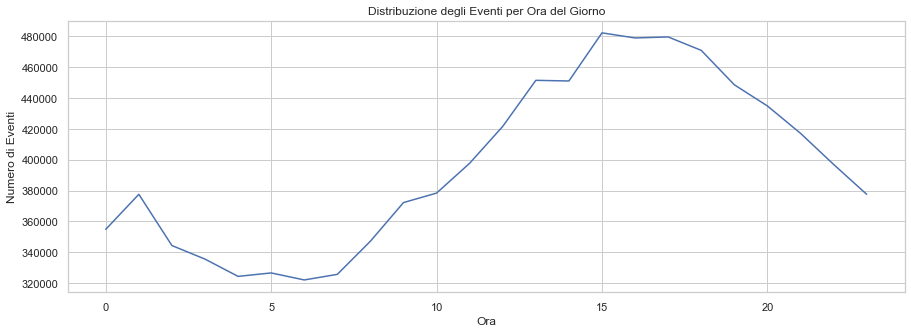

<Figure size 1080x432 with 0 Axes>

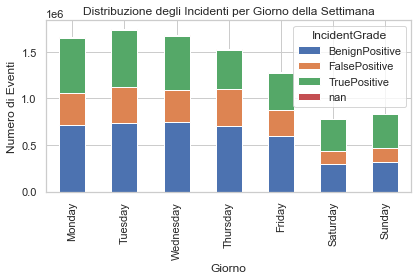

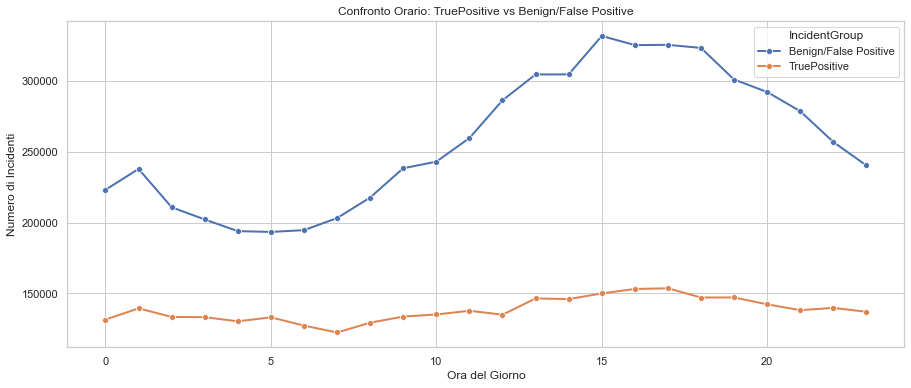

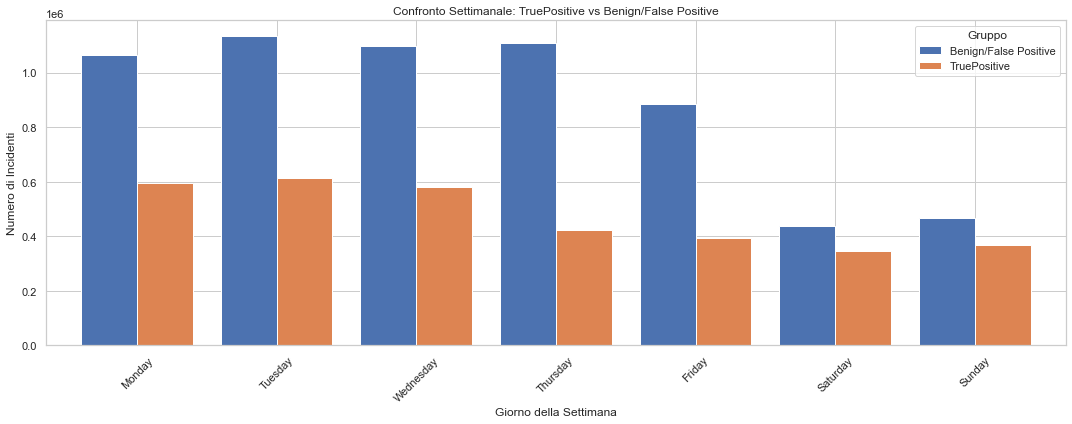


Statistiche Temporali:

Media eventi per ora: 396534
Ora più attiva: 15 con 482147 eventi
Ora meno attiva: 6 con 322094 eventi

Media eventi per giorno: 1359548
Giorno più attivo: Tuesday con 1748603 eventi
Giorno meno attivo: Saturday con 783065 eventi


In [4]:
# Conversione della colonna Timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.day_name()
df['Date'] = df['Timestamp'].dt.date
df['Month'] = df['Timestamp'].dt.month
df['Year'] = df['Timestamp'].dt.year

# Assicuriamoci che IncidentGrade sia di tipo stringa
df['IncidentGrade'] = df['IncidentGrade'].astype(str)

# Analisi per ora del giorno
plt.figure(figsize=(15, 5))
hourly_counts = df.groupby('Hour').size()
sns.lineplot(x=hourly_counts.index, y=hourly_counts.values)
plt.title('Distribuzione degli Eventi per Ora del Giorno')
plt.xlabel('Ora')
plt.ylabel('Numero di Eventi')
plt.grid(True)
plt.show()

# Analisi per giorno della settimana e tipo di incidente
plt.figure(figsize=(15, 6))
day_grade = pd.crosstab(df['DayOfWeek'], df['IncidentGrade'])
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_grade = day_grade.reindex(day_order)
day_grade.plot(kind='bar', stacked=True)
plt.title('Distribuzione degli Incidenti per Giorno della Settimana')
plt.xlabel('Giorno')
plt.ylabel('Numero di Eventi')
plt.legend(title='IncidentGrade')
plt.tight_layout()
plt.show()

# Creazione gruppo binario (TruePositive vs Altri)
# Raggruppiamo BenignPositive e FalsePositive in un'unica categoria per confronto
df['IncidentGroup'] = df['IncidentGrade'].apply(lambda x: 'TruePositive' if x == 'TruePositive' else 'Benign/False Positive')

# 1. Distribuzione oraria comparativa (TruePositive vs Gruppo)
plt.figure(figsize=(15, 6))
hourly_groups = df.groupby(['Hour', 'IncidentGroup']).size().reset_index(name='Count')
sns.lineplot(data=hourly_groups, x='Hour', y='Count', hue='IncidentGroup', marker='o', linewidth=2)
plt.title('Confronto Orario: TruePositive vs Benign/False Positive')
plt.xlabel('Ora del Giorno')
plt.ylabel('Numero di Incidenti')
plt.grid(True)
plt.show()

# 2. Distribuzione settimanale comparativa (TruePositive vs Gruppo)
daily_groups_pivot = pd.crosstab(df['DayOfWeek'], df['IncidentGroup']).reindex(day_order)

daily_groups_pivot.plot(kind='bar', figsize=(15, 6), width=0.8)
plt.title('Confronto Settimanale: TruePositive vs Benign/False Positive')
plt.xlabel('Giorno della Settimana')
plt.ylabel('Numero di Incidenti')
plt.legend(title='Gruppo')
plt.grid(True, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Statistiche temporali
print("\nStatistiche Temporali:")
print("\nMedia eventi per ora:", int(hourly_counts.mean()))
print("Ora più attiva:", hourly_counts.idxmax(), "con", hourly_counts.max(), "eventi")
print("Ora meno attiva:", hourly_counts.idxmin(), "con", hourly_counts.min(), "eventi")

daily_counts = df.groupby('DayOfWeek').size().reindex(day_order)
print("\nMedia eventi per giorno:", int(daily_counts.mean()))
print("Giorno più attivo:", daily_counts.idxmax(), "con", daily_counts.max(), "eventi")
print("Giorno meno attivo:", daily_counts.idxmin(), "con", daily_counts.min(), "eventi")

### Analisi Descrittiva AlertTitle
 Elenco dei valori possibili e top 10 più frequenti

=== Valori Univoci AlertTitle ===
Totale valori unici: 86149
[     6     43    298 ... 111967 112743 110883]

=== Top 10 AlertTitle più presenti ===


AlertTitle
0    1332232
1     774539
2     597497
4     413879
3     412087
5     334652
6     309093
7     145547
8     135410
9     117799
Name: count, dtype: int64

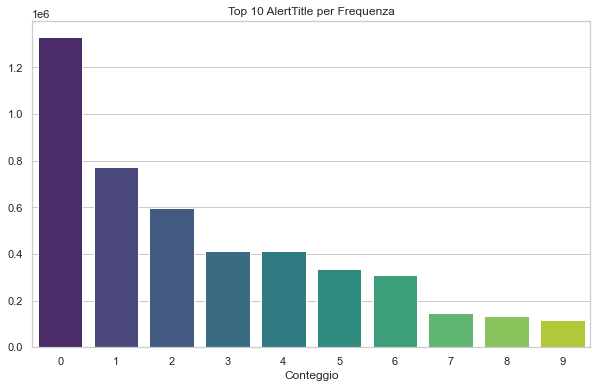

In [9]:

print("=== Valori Univoci AlertTitle ===")
unique_alerts = df['AlertTitle'].unique()
print(f"Totale valori unici: {len(unique_alerts)}")
# Se sono troppi, li stampiamo in modo ordinato o troncato, ma qui stampiamo l'array
print(unique_alerts)

print("\n=== Top 10 AlertTitle più presenti ===")
top_10_alerts = df['AlertTitle'].value_counts().head(10)
display(top_10_alerts)

# Grafico Top 10
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_alerts.index, y=top_10_alerts.values, palette='viridis')
plt.title('Top 10 AlertTitle per Frequenza')
plt.xlabel('Conteggio')
plt.show()

### Analisi Entità Tecniche (Device, File, IP, URL)

In [10]:
# ### Analisi Entità Tecniche (Device, File, IP, URL)
tech_cols = ['DeviceName', 'FileName', 'IpAddress', 'Url'] 
# Fallback ai nomi utente se standard non trovati: ['DevName', 'IpAddess']

for col in tech_cols:
    # Tentativo di recuperare la colonna corretta gestendo potenziali nomi diversi
    col_name = col
    if col not in df.columns:
        # Mapping manuale per nomi alternativi suggeriti dall'utente o comuni
        if col == 'DeviceName' and 'DevName' in df.columns: col_name = 'DevName'
        elif col == 'DeviceName' and 'DeviceId' in df.columns: col_name = 'DeviceId' # Fallback a ID se nome manca
        elif col == 'IpAddress' and 'IpAddess' in df.columns: col_name = 'IpAddess' # Typos utente
    
    if col_name in df.columns:
        print(f"\n=== Analisi: {col_name} ===")
        n_unique = df[col_name].nunique()
        n_null = df[col_name].isna().sum()

        print(f"Totale valori unici: {n_unique}")
        print(f"Valori Null: {n_null} ({n_null/len(df):.1%})")
        
        print(f"Top 10 {col_name} più presenti:")
        top_10 = df[col_name].value_counts().head(10)
        display(top_10)
    else:
         print(f"Attenzione: Colonna '{col}' non trovata nel dataset.")


=== Analisi: DeviceName ===
Totale valori unici: 114541
Valori Null: 0 (0.0%)
Top 10 DeviceName più presenti:


DeviceName
153085    8819646
0            4376
1            3944
5            2153
4            2152
6            1879
13           1727
7            1631
10           1545
9            1519
Name: count, dtype: int64


=== Analisi: FileName ===
Totale valori unici: 222085
Valori Null: 0 (0.0%)
Top 10 FileName più presenti:


FileName
289573    8487890
0           87736
1           71009
2           18194
3           15383
4           13041
5           10521
6           10090
9            7651
8            7579
Name: count, dtype: int64


=== Analisi: IpAddress ===
Totale valori unici: 285957
Valori Null: 0 (0.0%)
Top 10 IpAddress più presenti:


IpAddress
360606    7339164
0           12489
3            9868
1            9759
2            9246
4            7978
7            6974
5            6725
6            6681
8            5621
Name: count, dtype: int64


=== Analisi: Url ===
Totale valori unici: 123252
Valori Null: 0 (0.0%)
Top 10 Url più presenti:


Url
160396    8834131
0            8198
1            6607
2            5264
6            4238
3            3805
4            3465
5            3416
7            2335
9            2181
Name: count, dtype: int64

### Analisi Geografica (Country, State, City)


=== Analisi: CountryCode ===
Totale valori unici: 236
Valori Null: 0 (0.0%)
Top 10 CountryCode più presenti:


CountryCode
242    8766912
0       173218
1       106406
2        53671
4        40295
3        36406
5        33464
6        22877
7        19323
8        17934
Name: count, dtype: int64


=== Analisi: State ===
Totale valori unici: 1368
Valori Null: 0 (0.0%)
Top 10 State più presenti:


State
1445    8883778
0        103868
1         40312
2         28875
3         23048
4         19133
5         15771
6         15579
7         14495
8         12481
Name: count, dtype: int64


=== Analisi: City ===
Totale valori unici: 9342
Valori Null: 0 (0.0%)
Top 10 City più presenti:


City
10630    8883147
0         103433
1          22343
2          19449
3          15885
4          14468
5          13857
6          12009
7          11517
8          10837
Name: count, dtype: int64

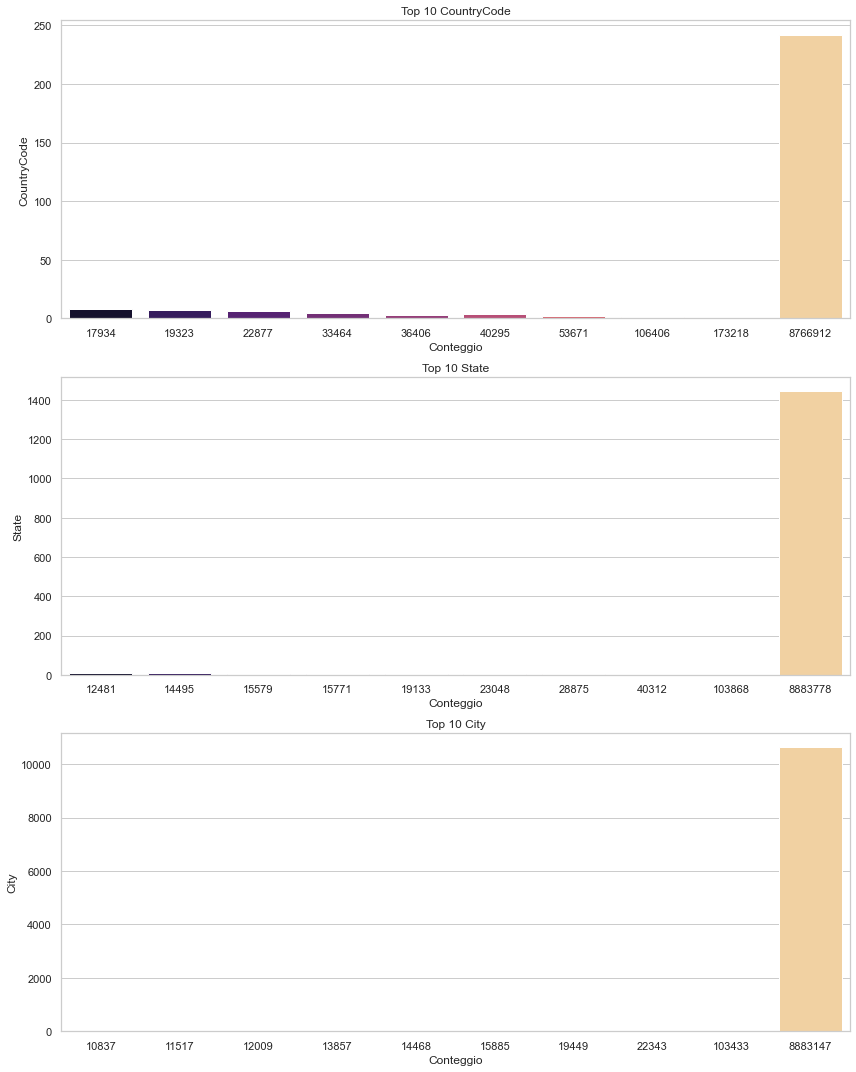

In [14]:
# ### Analisi Geografica (Country, State, City)
geo_cols = ['CountryCode', 'State', 'City']

# Filtriamo solo le colonne presenti nel dataset
cols_to_plot = [col for col in geo_cols if col in df.columns]

# Stampiamo avvisi per colonne mancanti
for col in geo_cols:
    if col not in df.columns:
        print(f"Attenzione: Colonna '{col}' non trovata nel dataset.")

if cols_to_plot:
    # Creiamo un'unica figura con num_rows = numero di colonne valide
    fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(12, 5 * len(cols_to_plot)))
    
    # Se abbiamo una sola colonna, axes non è una lista: normalizziamo
    if len(cols_to_plot) == 1:
        axes = [axes]
    
    for idx, col in enumerate(cols_to_plot):
        print(f"\n=== Analisi: {col} ===")
        n_unique = df[col].nunique()
        n_null = df[col].isna().sum()
        
        print(f"Totale valori unici: {n_unique}")
        print(f"Valori Null: {n_null} ({n_null/len(df):.1%})")
        
        top_10 = df[col].value_counts().head(10)
        print(f"Top 10 {col} più presenti:")
        display(top_10)
        
        # Plot nel sottografico corrispondente
        if len(top_10) > 0:
            sns.barplot(x=top_10.values, y=top_10.index, palette='magma', ax=axes[idx])
            axes[idx].set_title(f'Top 10 {col}')
            axes[idx].set_xlabel('Conteggio')

    plt.tight_layout()
    plt.show()

In [8]:
# ### Analisi MitreTechniques
# Copertura (Null vs Non-Null) ed esempi

col = 'MitreTechniques'

if col in df.columns:
    print(f"=== Analisi Copertura: {col} ===")
    total = len(df)
    non_null = df[col].count()
    null_count = df[col].isna().sum()
    
    print(f"Totale righe: {total}")
    print(f"Valori presenti (Non-Null): {non_null} ({non_null/total:.1%})")
    print(f"Valori mancanti (Null): {null_count} ({null_count/total:.1%})")
    
    print(f"\n=== 5 Esempi di {col} valorizzati ===")
    examples = df[df[col].notna()][col].head(5)
    for i, val in enumerate(examples, 1):
        print(f"{i}. {val}")
else:
    print(f"Colonna '{col}' non trovata nel DataFrame.")

=== Analisi Copertura: MitreTechniques ===
Totale righe: 9516837
Valori presenti (Non-Null): 4048451 (42.5%)
Valori mancanti (Null): 5468386 (57.5%)

=== 5 Esempi di MitreTechniques valorizzati ===
1. T1189
2. T1078;T1078.004
3. T1566
4. T1098;T1114
5. T1559;T1106;T1059.005


## Analisi delle Correlazioni

Analizziamo le correlazioni tra le variabili numeriche del dataset, con particolare attenzione alla colonna Risk.


In [ ]:
# Visualizziamo le colonne disponibili
print("Colonne nel dataset:")
print(df.columns.tolist())

# Selezione delle colonne numeriche
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

# Creazione della heatmap delle correlazioni
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matrice di Correlazione delle Variabili Numeriche')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Stampa delle correlazioni più significative
print("\nCorrelazioni più significative:")
for col in numeric_cols:
    top_corr = correlation_matrix[col].sort_values(ascending=False)[:3]
    print(f"\n{col}:")
    print(top_corr)